O autor utilizou o AI Asssitant da IDE PyCharm 2025.3.4, que usou o GPT 5.4 Mini, para debugar

In [5]:
import math
import os
from pathlib import Path

import PIL
import matplotlib.pyplot as plt #3.10.8
import matplotlib.image as imread
import seaborn as sns #0.13.2
import numpy as np #2.4.4
import pandas as pd #3.0.2
from PIL import Image #12.1.1


In [6]:
# Config dataset
TRAIN_PATH = Path('train')
TEST_PATH = Path('test')
LABELS_TRAIN_PATH = Path('labels', 'train_gabarito.csv')

Tamanho do dataset e distribuição de classes

In [7]:
files_train_gen = TRAIN_PATH.glob('*.*')
files_train_path_list = [file for file in files_train_gen]

files_test_gen = TEST_PATH.glob('*.*')
files_test_path_list = [file for file in files_test_gen]

print(f'Training size: {len(files_train_path_list)}')
print(f'Testing size: {len(files_test_path_list)}')

Training size: 279
Testing size: 70


In [8]:
labels_train_df = pd.read_csv(LABELS_TRAIN_PATH)
labels_train_df.head()


,Nome,Label
0,Good_good_tomato (28).jpg,1
1,Bad_bad_tomato (104).jpg,0
2,Bad_bad_tomato (1).jpg,0
3,Good_good_tomato (112).jpg,1
4,Good_good_tomato (126).jpg,1


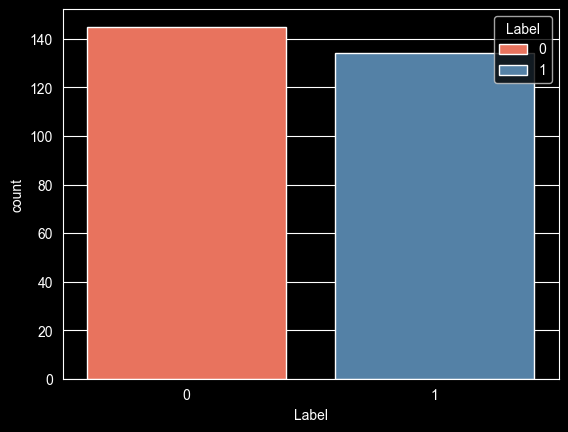

In [9]:
_ = sns.countplot(data=labels_train_df, x ='Label', hue='Label', palette={0: 'tomato', 1: 'steelblue'})
plt.show()

In [10]:
labels_train_df.value_counts(["Label"], normalize=True)

Label
0        0.519713
1        0.480287
Name: proportion, dtype: float64

Checks de sanidade

In [11]:
class SanityChecks:
    def __init__(self, path: Path) -> None:
        self.path = path
        self.files_list = self.__get_path_list()
        self.mode_types = []
        self.width = []
        self.height = []

    def __get_path_list(self) -> list:
        files_path_gen = self.path.glob('*.*')
        return [file for file in files_path_gen]

    def check_corruption(self) -> dict:
        error = []
        for file in self.files_list:
            try:
                img = Image.open(file)
                self.mode_types.append(img.mode)
                self.width.append(img.width)
                self.height.append(img.height)
            except:
                error.append(file)
        return {
            'qt_errors': len(error), 'files_erros': error}

    def check_typing(self) -> dict:
        print(self.files_list[0])
        ext = [str(file).split('.')[-1] for file in self.files_list]
        return {
            "ext": list(set(ext))
        }
    def check_mode(self) -> dict:
        return {
            'modes': list(set(self.mode_types))
        }

    def check_dimensions (self) -> dict:
        return {
            'width': list(set(self.width)),
            'height': list(set(self.height))
        }

In [12]:
sanity_checks = SanityChecks(TRAIN_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
train\Bad_bad_tomato (1).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}
{'width': [517, 523, 1548, 529, 532, 535, 2072, 1561, 538, 2076, 541, 1566, 543, 544, 546, 547, 2085, 1573, 1063, 552, 553, 1577, 556, 1068, 559, 562, 565, 1591, 573, 1601, 1092, 1609, 586, 1611, 1098, 595, 1110, 1626, 604, 607, 609, 2148, 613, 1639, 618, 619, 1642, 622, 628, 631, 1147, 1149, 2174, 658, 1684, 1699, 1701, 1704, 682, 1706, 1198, 1713, 690, 181, 694, 1205, 1718, 1720, 1214, 706, 1738, 1228, 1740, 2252, 1230, 1746, 214, 1753, 1754, 1756, 220, 1768, 745, 748, 1266, 1269, 249, 1275, 252, 256, 1792, 259, 773, 268, 1809, 276, 789, 1301, 279, 1304, 790, 1306, 277, 286, 1822, 289, 295, 300, 301, 1837, 304, 1842, 307, 1332, 1334, 830, 324, 836, 1351, 1866, 1867, 333, 334, 1870, 336, 337, 340, 1877, 1364, 343, 856, 345, 1367, 349, 862, 863, 358, 1384, 361, 1389, 367, 370, 372, 373, 1397, 375, 376, 379, 380, 381, 382, 1916, 1917, 385, 1405, 387, 390, 391, 394, 1419, 396, 397, 399, 1

In [13]:
sanity_checks = SanityChecks(TEST_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
test\Bad_bad_tomato (10).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}
{'width': [384, 1152, 514, 643, 645, 520, 394, 523, 268, 526, 1039, 400, 406, 280, 1689, 1436, 541, 1151, 418, 546, 1573, 1661, 1319, 426, 427, 1836, 1450, 1072, 447, 192, 448, 450, 1344, 580, 1735, 328, 456, 586, 2252, 1359, 466, 1875, 340, 1747, 472, 474, 1885, 1757, 1119, 358, 490, 1131, 364, 1389, 1262, 496, 370, 502, 247, 1402, 508, 253, 1791], 'height': [387, 520, 1032, 397, 1039, 403, 405, 1173, 535, 537, 282, 283, 412, 541, 286, 1310, 544, 1436, 1307, 1573, 421, 423, 171, 1836, 430, 432, 433, 1072, 1202, 310, 567, 439, 1210, 450, 453, 327, 1735, 328, 1099, 463, 1875, 1747, 342, 471, 1366, 601, 475, 1885, 1757, 1503, 352, 1379, 1381, 231, 487, 1131, 492, 1389, 1522, 499, 504, 505, 507, 508, 1661, 510, 1791]}


In [14]:
def plot_images(path: Path, sample_size: int):
    files_path_gen = path.glob('*.*')
    files = [file for file in files_path_gen]

    sample = np.random.choice(files, sample_size)

    cols = math.ceil(math.sqrt(sample_size))
    rows = math.ceil(math.sqrt(sample_size))

    plt.figure(figsize=(10,10))
    plt.suptitle(f'Sample of {sample_size} images from {path}')
    for i, file in enumerate(sample):
        img = Image.open(file)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

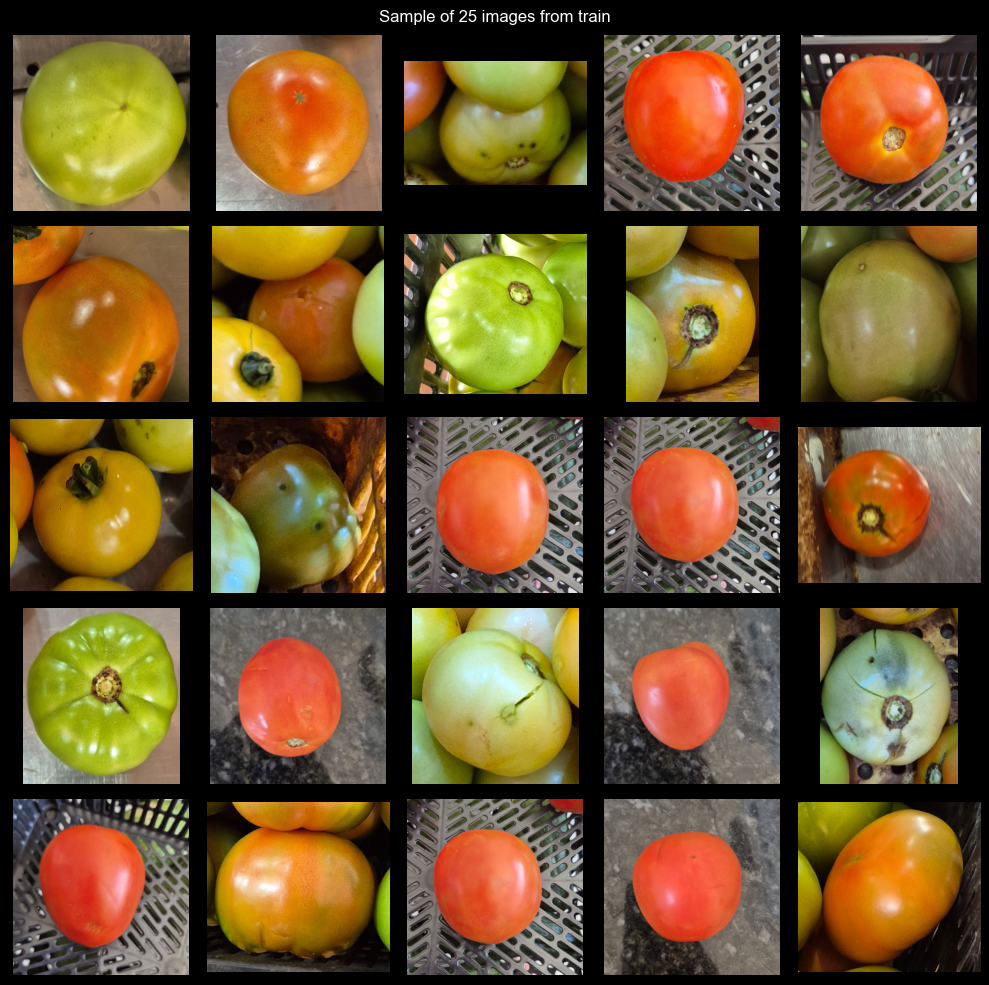

In [15]:
plot_images(TRAIN_PATH, sample_size=25)

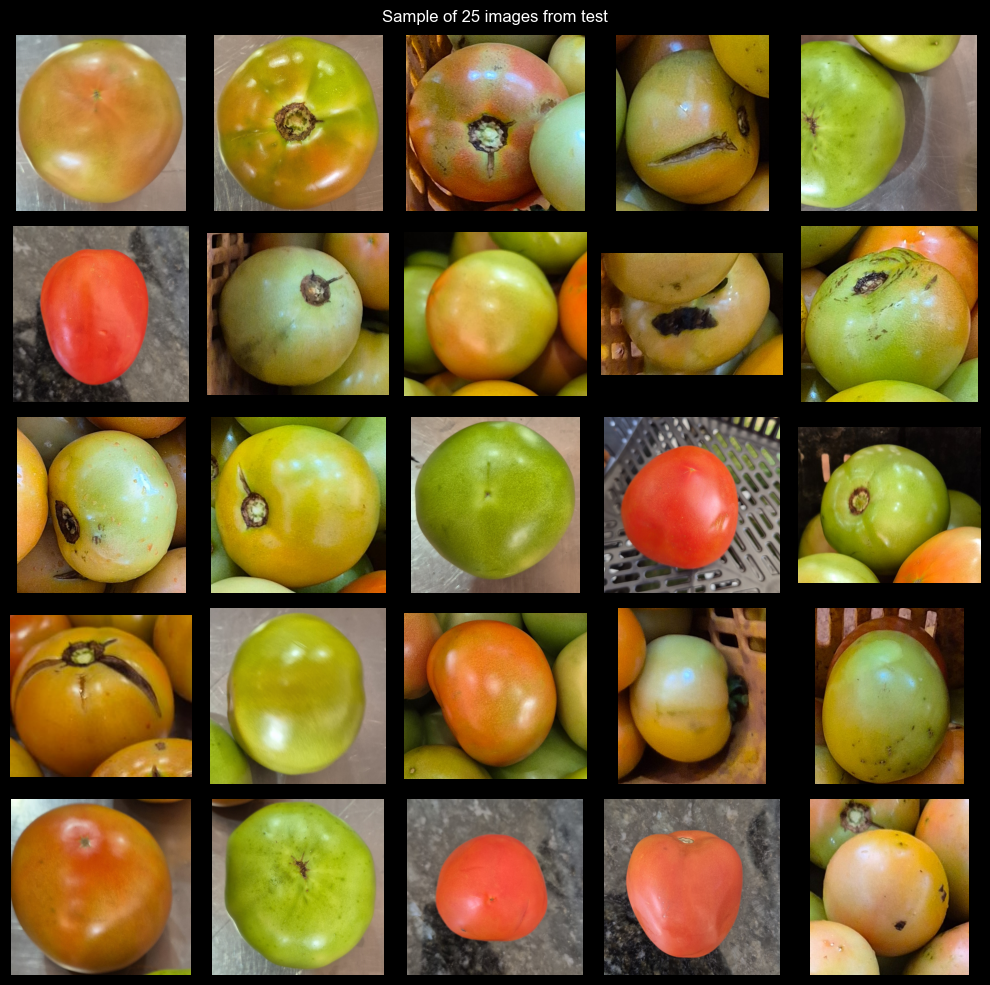

In [16]:
plot_images(TEST_PATH, sample_size=25)

Visualizando a distribuição de pixels

In [17]:
class PixelsVerify:
    def __init__(self, path: Path, labels_path: Path) -> None:
        self.train_path = path
        self.files = self.__get_path_list()
        self.labels_train_df = pd.read_csv(labels_path)
        self.sample = []
        self.rows = None
        self.cols = None

        self.labels_map = dict(
            zip(self.labels_train_df["Nome"], self.labels_train_df["Label"])
        )

    def __get_path_list(self) -> list:
        files_path_gen = self.train_path.glob("*.*")
        return [file for file in files_path_gen]

    def __get_rgb_pixels(self, image):
        pixels = image.histogram()
        return {
            "r": pixels[:256],
            "g": pixels[256:512],
            "b": pixels[512:]
        }

    def plot_histograms(self, sample_size):
        self.sample = np.random.choice(self.files, sample_size)

        # Pair each file with its labels directly
        samples_with_labels = [
            (file, self.labels_map.get(file.name, "unknown"))
            for file in self.sample
        ]

        self.cols = math.ceil(math.sqrt(sample_size))
        self.rows = math.ceil(math.sqrt(sample_size))

        plt.figure(figsize=(10, 10))
        plt.suptitle("Sample of histograms from database")

        for i, (file, label) in enumerate(samples_with_labels):
            img = Image.open(file)
            pixels = self.__get_rgb_pixels(img)

            plt.subplot(self.rows, self.cols, i + 1)
            plt.plot(list(range(256)), pixels["r"], color="Red")
            plt.plot(list(range(256)), pixels["g"], color="Green")
            plt.plot(list(range(256)), pixels["b"], color="Blue")
            plt.title(f"{file.name} - {label}")

        plt.tight_layout()
        plt.show()
    def plot_imgs_from_histograms(self):
        plt.figure(figsize=(10,10))
        plt.suptitle(f'Imagens aleatórias referentes aos histogramas')
        for i, file in enumerate(self.sample):
            img = Image.open(file)
            plt.subplot(self.rows, self.cols, i+1)
            plt.imshow(img)
            plt.title(file.name)
            plt.axis('off')

        plt.tight_layout()
        plt.show()


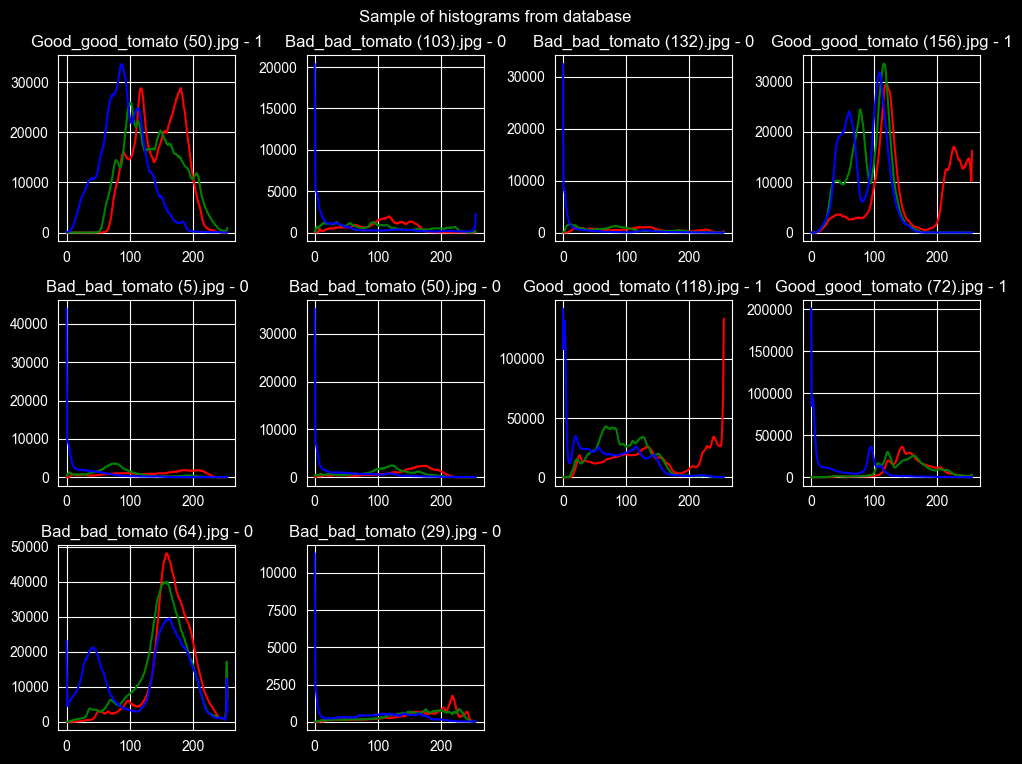

In [18]:
pixels = PixelsVerify(TRAIN_PATH, LABELS_TRAIN_PATH)
pixels.plot_histograms(sample_size=10)

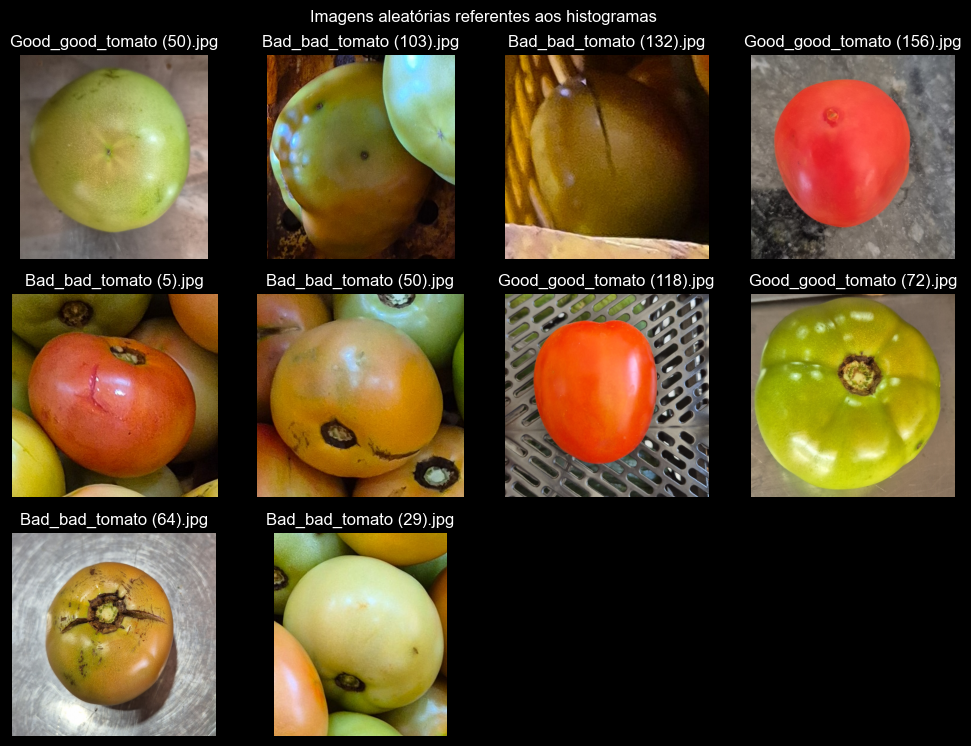

In [19]:
pixels.plot_imgs_from_histograms()